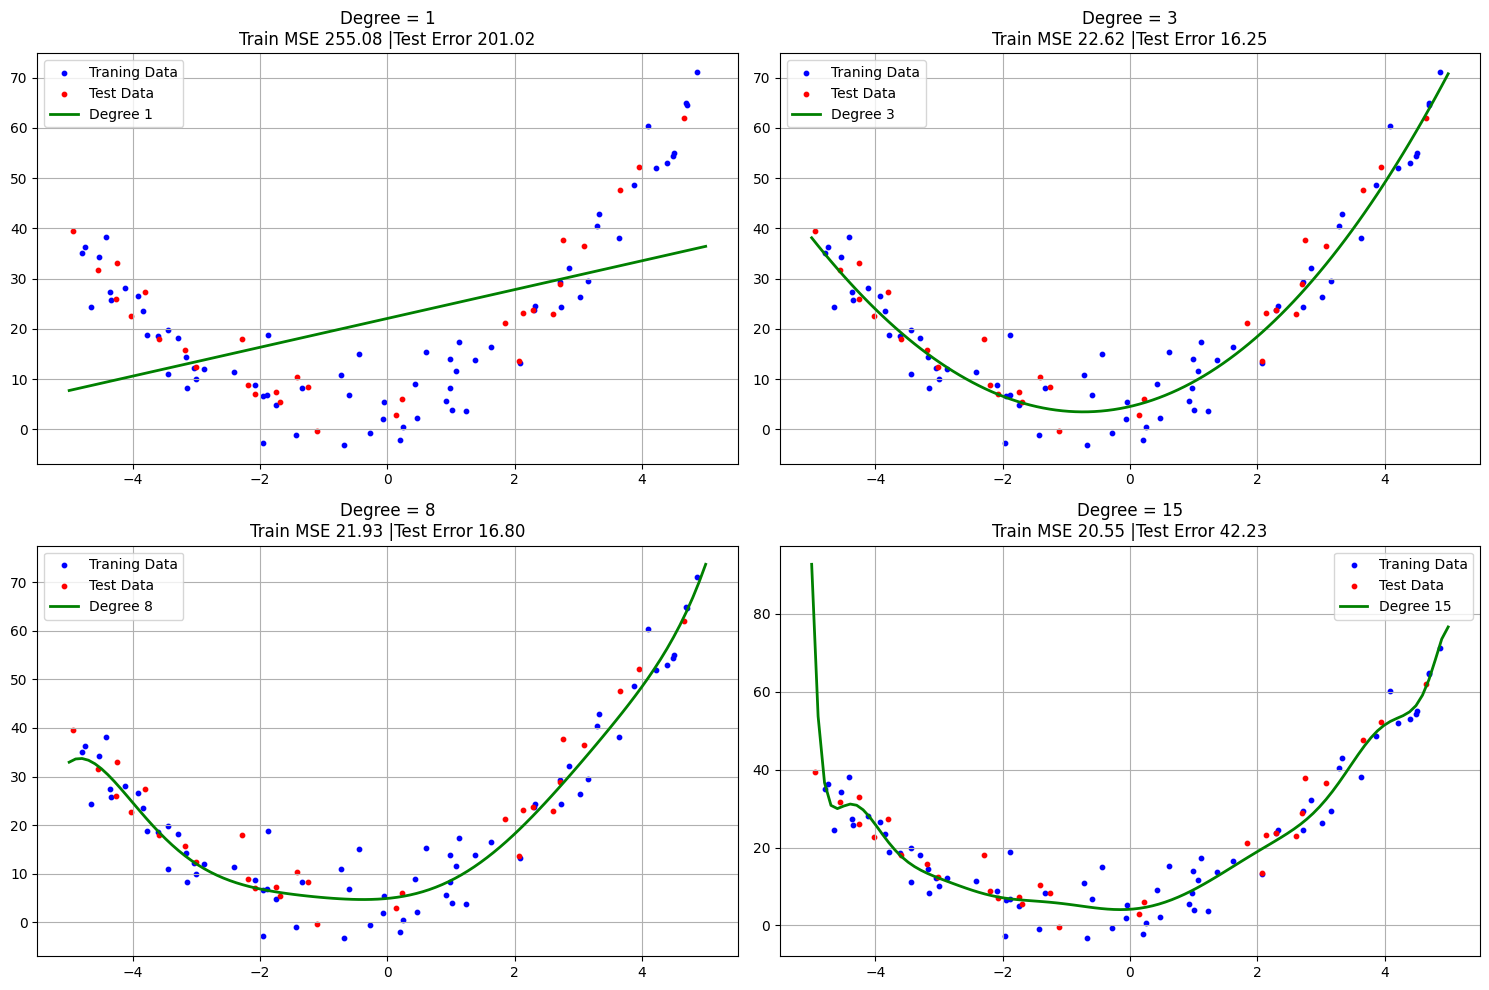

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.sort(np.random.rand(100,1)*10-5,axis=0) # value -5 to 5
y = 2 * X**2 + 3 * X + 5 + np.random.normal(0,5,(100,1)) # noise

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3, random_state=42)
degrees = [1,3,8,15] 
plt.figure(figsize=(15,10))
for i , degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree),LinearRegression())
    model.fit(X_train,y_train)
    
    # predictions 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_error = mean_squared_error(y_train,y_train_pred)
    test_error = mean_squared_error(y_test,y_test_pred)
    # plot
    plt.subplot(2 , 2 , i+1)
    plt.scatter(X_train,y_train,color="blue",label="Traning Data",s=10)
    plt.scatter(X_test,y_test,color='red',label="Test Data",s=10)
    
    X_plot = np.linspace(-5,5,100).reshape(-1,1)
    plt.plot(X_plot,model.predict(X_plot),color="green",linewidth=2,label=f"Degree {degree}")
    plt.title(f"Degree = {degree}\nTrain MSE {train_error:.2f} |Test Error {test_error:.2f}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()    
